In [2]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model
from ncmcm.bundlenet.utils import prep_data, timeseries_train_test_split


In [6]:
os.getcwd()

'/home/akshey/Desktop/PhD/Code_repositories/bundlenet_results/c_elegans_results/bundlenet_parameter_experiments'

   latent_dim  markov_train_loss  markov_test_loss  behaviour_train_loss  \
0           1           0.013759          0.012693              0.057127   
1           1           0.010752          0.020671              0.057281   
2           1           0.012788          0.010370              0.059644   
3           1           0.011442          0.022130              0.050913   
4           1           0.013772          0.022555              0.052333   

   behaviour_test_loss  total_train_loss  total_test_loss  
0             0.414313          0.070886         0.427006  
1             0.310472          0.068033         0.331143  
2             0.087153          0.072432         0.097523  
3             0.108687          0.062355         0.130817  
4             0.090710          0.066104         0.113265  


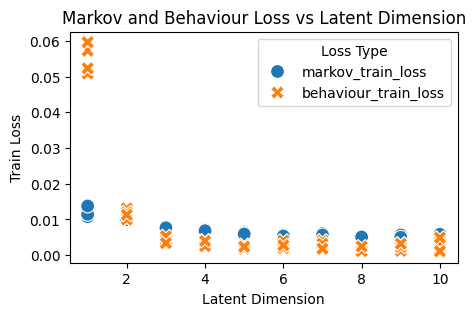

In [8]:
algorithm = 'BunDLeNet'
# Plotting
results = np.load(f'../../data/generated/bunlenet_parameter_experiments/losses_vs_latent_dim_{algorithm}.npy', allow_pickle=True)
df = pd.DataFrame.from_dict(list(results))
print(df.head())

df_melted = df.melt(id_vars='latent_dim', value_vars=['markov_train_loss', 'behaviour_train_loss'],
                    var_name='Loss Type', value_name='Loss')

plt.figure(figsize=(5, 3))
sns.scatterplot(data=df_melted, x='latent_dim', y='Loss', hue='Loss Type', style='Loss Type', s=100)
plt.xlabel('Latent Dimension')
plt.ylabel('Train Loss')
plt.title('Markov and Behaviour Loss vs Latent Dimension')
plt.show()